In [9]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# ======================
# Load Dataset
# ======================

df = pd.read_csv("../dataset/patient_data.csv")

print("Original Shape:", df.shape)

# Rename column
df.rename(columns={"C": "Gender"}, inplace=True)


# ======================
# Remove Duplicates
# ======================

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)


# ======================
# Clean Text
# ======================

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].str.strip()


# ======================
# Encode Categorical Data
# ======================

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])


# ======================
# Features & Target
# ======================

X = df.drop("Stages", axis=1)
y = df["Stages"]


# ======================
# Scaling
# ======================

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


# ======================
# Train Test Split
# ======================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


# ======================
# Train Model
# ======================

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)


# ======================
# Evaluation
# ======================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


# ======================
# Save Model
# ======================

joblib.dump(model, "../model/logreg_model.pkl")
joblib.dump(scaler, "../model/scaler.pkl")

print("Model saved successfully")

Original Shape: (1825, 14)
After removing duplicates: (1349, 14)
Accuracy: 0.9481481481481482
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       109
           1       1.00      0.95      0.98        84
           4       0.93      1.00      0.96        54
           5       1.00      0.57      0.72        23

    accuracy                           0.95       270
   macro avg       0.96      0.88      0.90       270
weighted avg       0.95      0.95      0.94       270

Model saved successfully


In [11]:
print(df['Stages'].unique())
print(df['Stages'].value_counts())

[0 1 4 2 3 5]
Stages
0    600
1    396
4    239
5    112
2      1
3      1
Name: count, dtype: int64


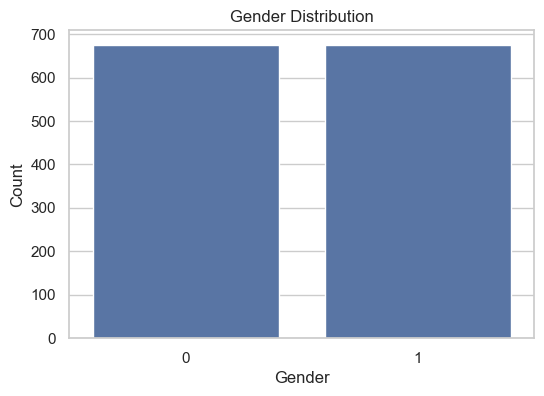

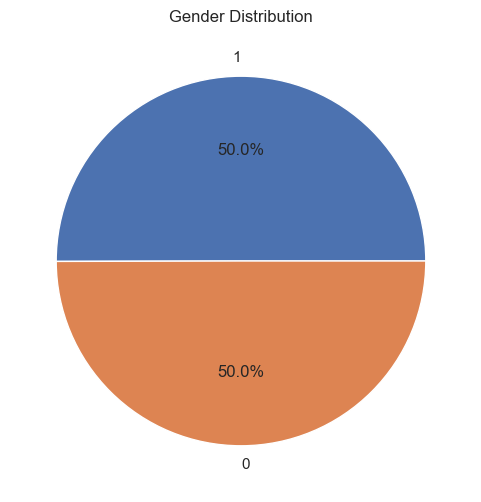

In [19]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style='whitegrid')
df1 = df
df1.rename(columns={"C":"Gender"},inplace=True)
df1.head()


# Gender Distribution 
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()



df["Gender"].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6),
    title="Gender Distribution"
)

plt.ylabel("")
plt.show()

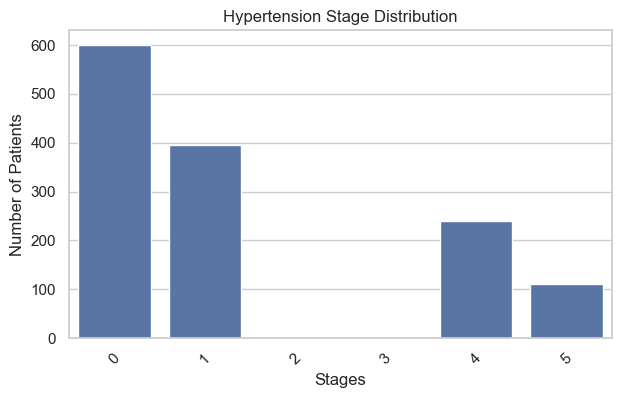

In [20]:
# Hypertension stages distribution
plt.figure(figsize=(7,4))

sns.countplot(x="Stages", data=df)

plt.title("Hypertension Stage Distribution")
plt.xlabel("Stages")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.show()

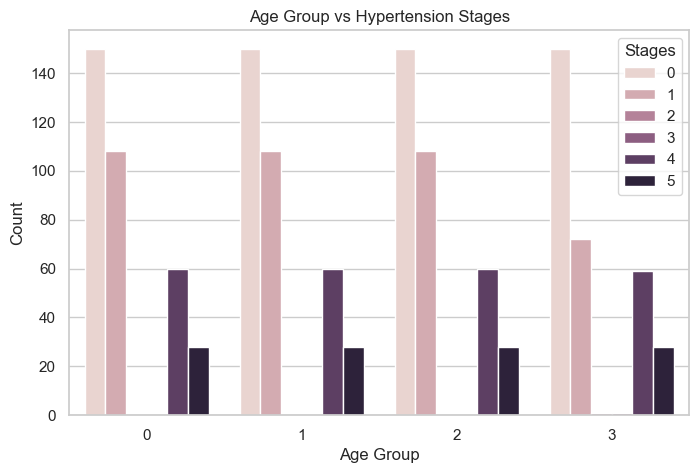

In [21]:
# Age group vs Hypertension stages
plt.figure(figsize=(8,5))

sns.countplot(x="Age", hue="Stages", data=df)

plt.title("Age Group vs Hypertension Stages")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

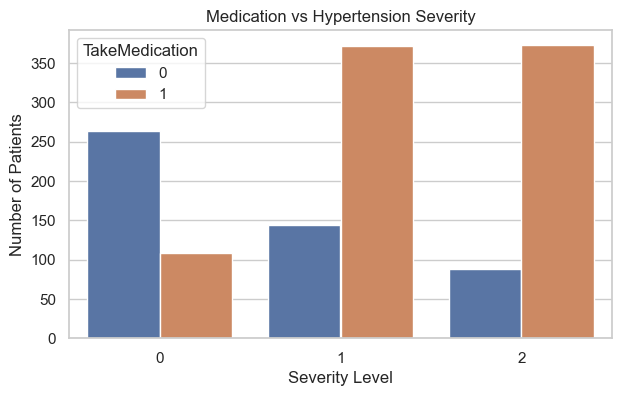

In [22]:
# Medication vs severity 
plt.figure(figsize=(7,4))

sns.countplot(x="Severity", hue="TakeMedication", data=df)

plt.title("Medication vs Hypertension Severity")
plt.xlabel("Severity Level")
plt.ylabel("Number of Patients")

plt.show()

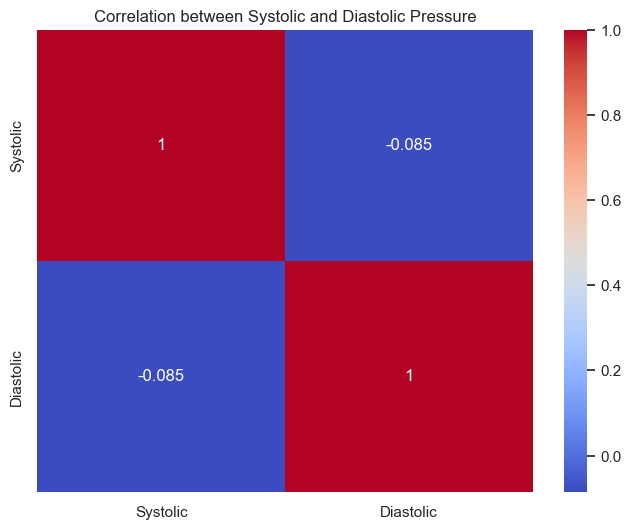

In [25]:
# correlation heatmap 
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Systolic","Diastolic"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation between Systolic and Diastolic Pressure")

plt.show()